# Notebook 01: Data Acquisition and Integrity Verification

### English

**Purpose**

- Acquire the dog and cat face subsets of AFHQ (Animal Faces-HQ) from a public Kaggle mirror, excluding the wildlife domain.
- Materialize the dataset as individual image files on disk, in a layout consistent with the rest of this pipeline.
- Verify the structural and content integrity of the retrieved data.
- Construct a consolidated manifest file — including a species label per image — that serves as the single reference for all subsequent notebooks.

**Data Source**

- Dataset: AFHQ (Animal Faces-HQ), introduced by Choi et al. (StarGAN v2, CVPR 2020) — a dataset purpose-built for high-quality image synthesis and image-to-image translation research, spanning three domains: cat, dog, and wildlife.
- Mirror used: `andrewmvd/animal-faces` on Kaggle, downloaded via the `kagglehub` library, using its `output_dir` option to download directly into this project rather than an external cache. This mirror bundles all three domains together (16,130 images total, roughly 5,000 per domain); this notebook keeps the dog and cat domains and discards wildlife.
- Coverage: approximately 10,000 face images (dog + cat combined), 512×512 pixels. Each image is labeled by species (`dog` or `cat`) in the manifest — this label is used later as a conditioning signal, since the project now supports a species selector (generate a dog face or a cat face on request) rather than a single unconditional output. Images are downsampled to the pipeline's target training resolution (128×128) during preprocessing in `03_preprocessing.ipynb`, not in this notebook.
- Licensing: CC BY-NC 4.0 (Attribution, Non-Commercial) as listed by the Kaggle uploader. Acceptable for this project's educational, non-commercial scope; any future reuse must remain non-commercial and provide attribution.

**Execution Environment**

- Runs locally; GPU acceleration is not required.
- No Kaggle authentication step is required for this specific download: `kagglehub.dataset_download` succeeds without calling `kagglehub.login()` first, since authentication is only enforced for private or consent-gated datasets, and this one is neither. (If Kaggle ever changes this dataset's access terms, `kagglehub.login()` can be called manually before Section 3's download cell — the token stays in memory only, never written to disk or saved into this notebook.)
- Approximately 2 GB of free disk space is recommended.

**Pipeline Steps**

- [ ] 1. Environment verification and dependency installation
- [ ] 2. Project directory configuration
- [ ] 3. Data acquisition (Kaggle, no authentication required)
- [ ] 4. Image export to disk (dog + cat subsets, species-labeled)
- [ ] 5. Data integrity verification and manifest construction
- [ ] 6. Preliminary sanity check
- [ ] 7. Manifest export

---

### Tiếng Việt

**Mục tiêu**

- Thu thập tập con ảnh mặt chó và mặt mèo của AFHQ (Animal Faces-HQ) từ một mirror công khai trên Kaggle, loại bỏ miền động vật hoang dã.
- Xuất bộ dữ liệu thành các file ảnh riêng lẻ trên đĩa, theo cấu trúc nhất quán với phần còn lại của pipeline.
- Kiểm tra tính toàn vẹn về cấu trúc và nội dung của dữ liệu thu thập được.
- Xây dựng một tệp manifest hợp nhất — có nhãn loài cho từng ảnh — đóng vai trò tài liệu tham chiếu duy nhất cho toàn bộ các notebook tiếp theo.

**Nguồn dữ liệu**

- Bộ dữ liệu: AFHQ (Animal Faces-HQ), do Choi và cộng sự công bố (StarGAN v2, CVPR 2020) — bộ dữ liệu được xây dựng riêng cho nghiên cứu tổng hợp ảnh chất lượng cao và image-to-image translation, gồm 3 miền: mèo, chó, và động vật hoang dã.
- Mirror sử dụng: `andrewmvd/animal-faces` trên Kaggle, tải qua thư viện `kagglehub`, dùng tùy chọn `output_dir` để tải thẳng vào project thay vì cache bên ngoài. Mirror này gộp chung cả 3 miền (tổng 16.130 ảnh, mỗi miền khoảng 5.000 ảnh); notebook này giữ lại miền chó và mèo, bỏ miền động vật hoang dã.
- Phạm vi: khoảng 10.000 ảnh khuôn mặt (chó + mèo gộp lại), 512×512 pixel. Mỗi ảnh được gán nhãn loài (`dog` hoặc `cat`) trong manifest — nhãn này sẽ dùng làm tín hiệu điều kiện (conditioning) sau này, vì dự án hiện hỗ trợ bộ chọn loài (generate ảnh chó hoặc ảnh mèo theo yêu cầu) thay vì chỉ ra một kết quả không điều kiện duy nhất. Ảnh sẽ được resize xuống độ phân giải huấn luyện mục tiêu của pipeline (128×128) ở bước tiền xử lý trong `03_preprocessing.ipynb`, không phải ở notebook này.
- Bản quyền: CC BY-NC 4.0 (ghi công tác giả, phi thương mại) theo người upload trên Kaggle. Phù hợp với mục đích học tập/phi thương mại của dự án; mọi sử dụng sau này cần duy trì tính phi thương mại và ghi công tác giả gốc.

**Môi trường thực thi**

- Chạy trên máy cục bộ (local); không yêu cầu GPU.
- Không cần bước xác thực Kaggle nào cho lượt tải cụ thể này: `kagglehub.dataset_download` chạy thành công mà không cần gọi `kagglehub.login()` trước, vì xác thực chỉ bắt buộc với dataset private hoặc cần đồng ý điều khoản, còn dataset này thì không. (Nếu sau này Kaggle thay đổi điều kiện truy cập dataset này, có thể gọi `kagglehub.login()` thủ công trước cell tải ở Mục 3 — token chỉ lưu trong bộ nhớ, không bao giờ ghi ra đĩa hay lưu vào notebook.)
- Khuyến nghị khoảng 2 GB dung lượng ổ đĩa trống.

**Các bước trong pipeline**

- [ ] 1. Kiểm tra môi trường và cài đặt thư viện phụ thuộc
- [ ] 2. Thiết lập cấu trúc thư mục dự án
- [ ] 3. Thu thập dữ liệu (Kaggle, không cần xác thực)
- [ ] 4. Xuất ảnh ra đĩa (tập con chó + mèo, có gán nhãn loài)
- [ ] 5. Kiểm tra tính toàn vẹn dữ liệu và xây dựng manifest
- [ ] 6. Kiểm tra sơ bộ
- [ ] 7. Xuất tệp manifest


## 1. Environment Verification and Dependency Installation

### English

**Objective**

- Confirm that the Python packages required for this notebook are available.
- Automatically install any missing dependency.

---

### Tiếng Việt

**Mục tiêu**

- Xác nhận các thư viện Python cần thiết cho notebook đã sẵn sàng.
- Tự động cài đặt các thư viện còn thiếu.


In [1]:
import importlib
import subprocess
import sys

REQUIRED = ["kagglehub", "PIL", "pandas", "matplotlib", "tqdm"]
PIP_NAMES = {"PIL": "pillow"}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAMES.get(mod, mod))

if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    print("All required packages are already available.")


All required packages are already available.


## 2. Project Directory Configuration

### English

**Objective**

- Resolve the project root directory relative to the notebook's location.
- Create the directories used to store raw data and exported images, if they do not already exist.

---

### Tiếng Việt

**Mục tiêu**

- Xác định thư mục gốc của dự án dựa trên vị trí của notebook.
- Tạo các thư mục lưu dữ liệu thô và ảnh xuất ra, nếu chưa tồn tại.


In [2]:
from pathlib import Path

# Assume this notebook resides in notebooks/, so the project root is the parent directory
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
IMAGES_DIR = DATA_RAW / "images"
STAGING_DIR = DATA_RAW / "_kaggle_staging"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Data raw dir : {DATA_RAW}")
print(f"Images dir   : {IMAGES_DIR}")
print(f"Staging dir  : {STAGING_DIR}")


Project root : d:\Images by GAN\dog-gan-project
Data raw dir : d:\Images by GAN\dog-gan-project\data\raw
Images dir   : d:\Images by GAN\dog-gan-project\data\raw\images
Staging dir  : d:\Images by GAN\dog-gan-project\data\raw\_kaggle_staging


## 3. Data Acquisition

### English

**Objective**

- Download the AFHQ mirror dataset directly into this project via `kagglehub`.

**Notes**

- Most public Kaggle datasets — including this one — can be downloaded directly with `kagglehub.dataset_download(...)` and require no authentication at all; `kagglehub` only enforces login for private datasets or ones gated behind a consent/terms acceptance step. This was confirmed both by testing this exact dataset and by inspecting another local project that calls the same function successfully with no login step.
- The `output_dir` argument makes `kagglehub` download straight into this project's `data/raw/_kaggle_staging/` folder, bypassing its own external cache directory — matching the download approach used elsewhere in this project's surrounding codebase.
- This mirror bundles all three AFHQ domains (cat, dog, wildlife) into a single download; there is no way to fetch only a subset of domains from `kagglehub` directly, so Section 4 filters the staged files afterward, keeping dog and cat and discarding wildlife.
- Download size is approximately 696 MB (all three domains combined); the wildlife portion is deleted after filtering in Section 4 to reclaim disk space.

**Output**

- A local filesystem path (`data/raw/_kaggle_staging/`) containing all three AFHQ domains.

---

### Tiếng Việt

**Mục tiêu**

- Tải bộ dữ liệu mirror AFHQ trực tiếp vào project qua `kagglehub`.

**Lưu ý**

- Phần lớn dataset public trên Kaggle — bao gồm cả dataset này — tải được trực tiếp bằng `kagglehub.dataset_download(...)` mà không cần xác thực gì cả; `kagglehub` chỉ bắt buộc đăng nhập với dataset private hoặc dataset yêu cầu đồng ý điều khoản trước khi tải. Điều này đã được xác nhận qua việc thử trực tiếp với dataset này, và qua việc kiểm tra một project cục bộ khác gọi cùng hàm này thành công mà không cần bước đăng nhập.
- Tham số `output_dir` giúp `kagglehub` tải thẳng vào thư mục `data/raw/_kaggle_staging/` của project này, bỏ qua thư mục cache riêng của nó — khớp với cách tải dữ liệu đã dùng ở phần khác trong codebase của dự án này.
- Mirror này gộp chung cả 3 miền AFHQ (mèo, chó, động vật hoang dã) vào một lượt tải; không có cách nào để `kagglehub` chỉ tải riêng một vài miền, nên Mục 4 sẽ lọc lại các file đã tải, giữ chó và mèo, bỏ động vật hoang dã.
- Dung lượng tải khoảng 696 MB (cả 3 miền cộng lại); phần động vật hoang dã sẽ bị xóa sau khi lọc ở Mục 4 để giải phóng dung lượng đĩa.

**Kết quả**

- Một đường dẫn hệ thống tệp cục bộ (`data/raw/_kaggle_staging/`) chứa cả 3 miền của AFHQ.


In [3]:
import kagglehub

kaggle_dataset_path = kagglehub.dataset_download(
    "andrewmvd/animal-faces",
    output_dir=str(STAGING_DIR),
)

print(f"Dataset downloaded to: {kaggle_dataset_path}")


100%|██████████| 696M/696M [00:38<00:00, 18.8MB/s] 

Extracting files...


Dataset downloaded to: d:\Images by GAN\dog-gan-project\data\raw\_kaggle_staging


## 4. Image Export to Disk

### English

**Objective**

- Locate every dog- and cat-domain image within the staged AFHQ mirror (excluding wildlife) and move it into this project's `data/raw/images/`, recording each image's species.

**Notes**

- The species of each image is identified by checking its immediate parent folder name for "dog" or "cat" (case-insensitive), since this mirror organizes images by domain folder (and possibly by a train/validation split above that); this filter is intentionally structure-tolerant rather than assuming one fixed folder depth. Files whose parent folder name matches neither (i.e. the wildlife domain) are skipped entirely.
- Destination filenames are prefixed with the species and a running index (`dog_00000_...`, `cat_00000_...`), so species is recoverable directly from the filename in addition to being recorded in the manifest, and so that filenames stay unique even if the source mirror's train/validation splits reuse names.
- Files are **moved**, not copied, since they were staged directly into this project in Section 3 — there is no external cache copy left behind to preserve, so moving avoids doubling disk usage.
- The staging directory (including the discarded wildlife images) is removed after the move completes, to reclaim disk space.
- If `data/raw/images/` already contains the expected number of files, the export step is skipped to avoid redundant work on re-runs.

**Output**

- Approximately 10,000 image files under `data/raw/images/` (dog and cat domains only), named with a `dog_`/`cat_` species prefix.

---

### Tiếng Việt

**Mục tiêu**

- Xác định toàn bộ ảnh thuộc miền "dog" và "cat" trong mirror AFHQ đã tải (loại bỏ miền động vật hoang dã) và di chuyển vào `data/raw/images/` của project, đồng thời ghi lại loài của từng ảnh.

**Lưu ý**

- Loài của mỗi ảnh được xác định bằng cách kiểm tra tên thư mục cha trực tiếp của file ảnh có chứa "dog" hay "cat" hay không (không phân biệt hoa/thường), vì mirror này tổ chức ảnh theo thư mục miền (và có thể theo split train/validation ở cấp trên nữa); cách lọc này cố tình không giả định một độ sâu thư mục cố định. File nào có thư mục cha không khớp cả hai (tức thuộc miền động vật hoang dã) sẽ bị bỏ qua hoàn toàn.
- Tên file đích được thêm tiền tố là loài và chỉ số tăng dần (`dog_00000_...`, `cat_00000_...`), để loài có thể xác định trực tiếp từ tên file bên cạnh việc đã ghi trong manifest, đồng thời đảm bảo không trùng tên file kể cả khi các split train/validation của mirror gốc dùng trùng tên.
- File được **di chuyển (move)**, không phải sao chép, vì đã được tải thẳng vào project này ở Mục 3 — không có bản cache ngoài nào cần giữ lại, nên di chuyển giúp tránh nhân đôi dung lượng đĩa.
- Thư mục staging (bao gồm cả ảnh động vật hoang dã đã loại bỏ) sẽ được xóa sau khi di chuyển xong, để giải phóng dung lượng đĩa.
- Nếu `data/raw/images/` đã có đủ số lượng file mong đợi, bước xuất ảnh sẽ được bỏ qua để tránh lặp lại công việc khi chạy lại notebook.

**Kết quả**

- Khoảng 10.000 file ảnh trong `data/raw/images/` (chỉ miền chó và mèo), đặt tên có tiền tố loài `dog_`/`cat_`.


In [4]:
import shutil
from pathlib import Path
from tqdm.auto import tqdm

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}
SPECIES_FOLDERS = {"dog", "cat"}  # wildlife is intentionally excluded

source_root = Path(kaggle_dataset_path)


def detect_species(parent_folder_name: str) -> str | None:
    name = parent_folder_name.lower()
    for species in SPECIES_FOLDERS:
        if species in name:
            return species
    return None


source_files = []
for p in source_root.rglob("*"):
    if not p.is_file() or p.suffix.lower() not in IMAGE_EXTENSIONS:
        continue
    species = detect_species(p.parent.name)
    if species is not None:
        source_files.append((p, species))

source_files.sort(key=lambda pair: str(pair[0]))
expected_count = len(source_files)
print(f"Found {expected_count} dog/cat image files under {source_root}")

existing_count = len(list(IMAGES_DIR.glob("*")))

if existing_count >= expected_count:
    print(f"Found {existing_count} existing files, matching expected count — skipping export.")
else:
    print(f"Moving {expected_count} images into {IMAGES_DIR} ...")
    species_counters = {"dog": 0, "cat": 0}
    for src_path, species in tqdm(source_files, desc="Moving images"):
        idx = species_counters[species]
        species_counters[species] += 1
        dst_path = IMAGES_DIR / f"{species}_{idx:05d}_{src_path.name}"
        if not dst_path.exists():
            shutil.move(str(src_path), str(dst_path))
    print("Move complete.")
    print(f"  dog images: {species_counters['dog']}")
    print(f"  cat images: {species_counters['cat']}")

# Clean up the staging directory (discarded wildlife images and now-empty folders)
if STAGING_DIR.exists():
    shutil.rmtree(STAGING_DIR, ignore_errors=True)
    print(f"Removed staging directory: {STAGING_DIR}")


Found 10892 dog/cat image files under d:\Images by GAN\dog-gan-project\data\raw\_kaggle_staging
Moving 10892 images into d:\Images by GAN\dog-gan-project\data\raw\images ...


Moving images:   0%|          | 0/10892 [00:00<?, ?it/s]

Move complete.
  dog images: 5239
  cat images: 5653
Removed staging directory: d:\Images by GAN\dog-gan-project\data\raw\_kaggle_staging


## 5. Data Integrity Verification and Manifest Construction

### English

**Objective**

- Attempt to decode every exported image to confirm it is not corrupted.
- Record, for each image: file path, species, dimensions, file size, and a validity flag.

**Notes**

- Species is recovered directly from the filename prefix (`dog_`/`cat_`) established during export in Section 4, rather than re-deriving it from folder structure — the images now live in a single flat directory.
- Unlike the earlier version of this project, this manifest now carries a `species` column, since generation is conditional on species (a dog/cat selector) rather than fully unconditional.

**Output**

- An in-memory manifest table (`manifest`), later exported to `data/raw/manifest.csv` in Section 7.

---

### Tiếng Việt

**Mục tiêu**

- Thử giải mã từng ảnh đã xuất ra để xác nhận ảnh không bị hỏng.
- Ghi lại, với mỗi ảnh: đường dẫn, loài, kích thước, dung lượng, và cờ hợp lệ.

**Lưu ý**

- Loài được xác định trực tiếp từ tiền tố tên file (`dog_`/`cat_`) đã gán ở bước xuất ảnh tại Mục 4, thay vì suy ra lại từ cấu trúc thư mục — ảnh giờ nằm chung trong một thư mục phẳng duy nhất.
- Khác với phiên bản trước của project này, manifest hiện có thêm cột `species`, vì việc sinh ảnh giờ có điều kiện theo loài (bộ chọn chó/mèo) thay vì hoàn toàn không điều kiện.

**Kết quả**

- Bảng manifest trong bộ nhớ (`manifest`), sẽ được xuất ra `data/raw/manifest.csv` ở Mục 7.


In [5]:
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

image_paths = sorted(p for p in IMAGES_DIR.glob("*") if p.is_file())
print(f"Total image files to check: {len(image_paths)}")

records = []
for img_path in tqdm(image_paths, desc="Validating images"):
    species = img_path.name.split("_", 1)[0] if "_" in img_path.name else None
    record = {
        "filepath": str(img_path.relative_to(PROJECT_ROOT)),
        "species": species,
        "filesize_kb": round(img_path.stat().st_size / 1024, 1),
        "width": None,
        "height": None,
        "is_valid": False,
        "error": None,
    }
    try:
        with Image.open(img_path) as im:
            im.verify()
        # verify() invalidates the file handle for further reads, so reopen to read actual dimensions
        with Image.open(img_path) as im2:
            record["width"], record["height"] = im2.size
        record["is_valid"] = True
    except Exception as exc:  # noqa: BLE001 - intentionally broad: any decoding failure marks the image invalid
        record["error"] = str(exc)

    records.append(record)

manifest = pd.DataFrame(records)
print(f"\nFinished checking {len(manifest)} images.")


Total image files to check: 10892


Validating images:   0%|          | 0/10892 [00:00<?, ?it/s]


Finished checking 10892 images.


In [6]:
n_valid = manifest["is_valid"].sum()
n_invalid = (~manifest["is_valid"]).sum()

print(f"Valid images          : {n_valid}")
print(f"Invalid/corrupt images: {n_invalid}")
print()
print("Species breakdown (valid images only):")
print(manifest.loc[manifest["is_valid"], "species"].value_counts())

if n_invalid > 0:
    print("\nSample of invalid images (up to 10 rows):")
    display(manifest.loc[~manifest["is_valid"], ["filepath", "species", "error"]].head(10))
else:
    print("\nNo invalid images detected in the dataset.")


Valid images          : 10892
Invalid/corrupt images: 0

Species breakdown (valid images only):
species
cat    5653
dog    5239
Name: count, dtype: int64

No invalid images detected in the dataset.


## 6. Preliminary Sanity Check

### English

**Objective**

- Visually confirm that the export and validation steps produced usable data, by displaying a grid of randomly sampled images from each species.
- Check that image dimensions are consistent across the dataset (all should be 512×512, the resolution shipped by this Kaggle mirror — resizing to the pipeline's 128×128 training resolution happens later, in `03_preprocessing.ipynb`).

**Notes**

- A per-species sample grid (rather than one mixed grid) makes it easy to visually sanity-check both classes independently, given generation will be conditioned on species. Full exploratory analysis (color characteristics, blur/brightness distribution, duplicate detection, per-species comparison) is conducted separately in Notebook 02.

**Output**

- `reports/figures/01_sample_grid.png`

---

### Tiếng Việt

**Mục tiêu**

- Xác nhận trực quan rằng các bước xuất ảnh và kiểm tra đã tạo ra dữ liệu dùng được, bằng cách hiển thị lưới ảnh lấy mẫu ngẫu nhiên cho từng loài.
- Kiểm tra kích thước ảnh có nhất quán trong toàn bộ dataset không (tất cả phải là 512×512, độ phân giải mà mirror Kaggle này cung cấp — việc resize xuống độ phân giải huấn luyện 128×128 của pipeline sẽ diễn ra sau, ở `03_preprocessing.ipynb`).

**Lưu ý**

- Lưới ảnh mẫu tách riêng theo từng loài (thay vì một lưới trộn lẫn) giúp dễ kiểm tra trực quan độc lập cho cả hai lớp, vì việc sinh ảnh sẽ có điều kiện theo loài. Phân tích khám phá dữ liệu đầy đủ (đặc trưng màu sắc, phân bố độ mờ/độ sáng, phát hiện ảnh trùng lặp, so sánh giữa các loài) được thực hiện riêng ở Notebook 02.

**Kết quả**

- `reports/figures/01_sample_grid.png`


Unique image dimensions found:
   width  height
0    512     512


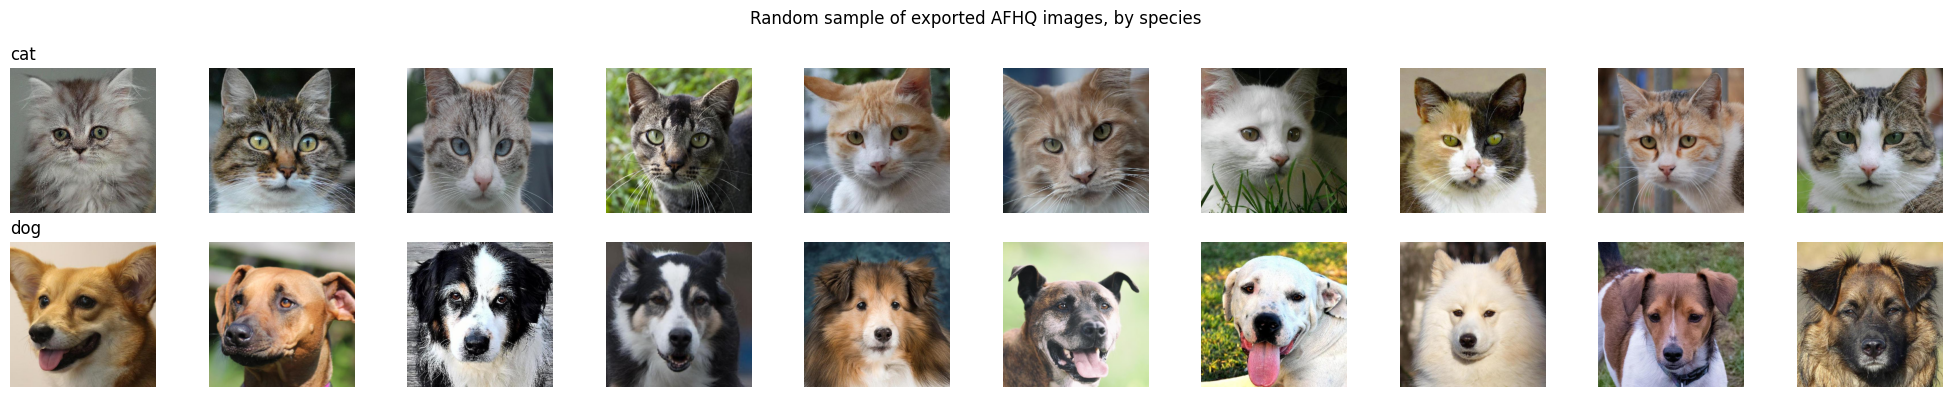

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

valid_manifest = manifest[manifest["is_valid"]]

unique_sizes = valid_manifest[["width", "height"]].drop_duplicates()
print("Unique image dimensions found:")
print(unique_sizes)

species_list = sorted(valid_manifest["species"].dropna().unique())
n_species = len(species_list)
n_per_species = 10

fig, axes = plt.subplots(n_species, n_per_species, figsize=(2 * n_per_species, 2 * n_species))
if n_species == 1:
    axes = axes[None, :]

for row_idx, species in enumerate(species_list):
    species_rows = valid_manifest[valid_manifest["species"] == species].sample(
        n=n_per_species, random_state=42
    )
    for col_idx, (_, row) in enumerate(species_rows.iterrows()):
        ax = axes[row_idx, col_idx]
        img = Image.open(PROJECT_ROOT / row["filepath"])
        ax.imshow(img)
        ax.axis("off")
        if col_idx == 0:
            ax.set_title(species, loc="left", fontsize=12)

plt.suptitle("Random sample of exported AFHQ images, by species")
plt.tight_layout()
fig_path = PROJECT_ROOT / "reports" / "figures"
fig_path.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path / "01_sample_grid.png", dpi=150)
plt.show()


## 7. Manifest Export

### English

**Objective**

- Export the compiled manifest to a CSV file, the canonical data reference for all subsequent notebooks.

**Output**

- `data/raw/manifest.csv`

---

### Tiếng Việt

**Mục tiêu**

- Xuất manifest đã tổng hợp ra tệp CSV, làm tài liệu dữ liệu tham chiếu chính thức cho toàn bộ notebook tiếp theo.

**Kết quả**

- `data/raw/manifest.csv`


In [8]:
manifest_path = DATA_RAW / "manifest.csv"
manifest.to_csv(manifest_path, index=False)
print(f"Manifest saved to: {manifest_path}")
print(f"Rows: {len(manifest)}  |  Columns: {len(manifest.columns)}")
manifest.head()


Manifest saved to: d:\Images by GAN\dog-gan-project\data\raw\manifest.csv
Rows: 10892  |  Columns: 7


,filepath,species,filesize_kb,width,height,is_valid,error
0,data\raw\images\cat_00000_flickr_cat_000002.jpg,cat,26.7,512,512,True,None
1,data\raw\images\cat_00001_flickr_cat_000003.jpg,cat,35.1,512,512,True,None
2,data\raw\images\cat_00002_flickr_cat_000004.jpg,cat,43.4,512,512,True,None
3,data\raw\images\cat_00003_flickr_cat_000005.jpg,cat,40.1,512,512,True,None
4,data\raw\images\cat_00004_flickr_cat_000006.jpg,cat,46.2,512,512,True,None


## Summary

### English

**Completed**

- Downloaded the AFHQ mirror dataset (`andrewmvd/animal-faces`) directly into this project via `kagglehub`, with no authentication step required.
- Filtered the download down to the dog and cat domains only (~10,000 images, 512×512), discarding the bundled wildlife domain to reclaim disk space.
- Moved every dog/cat image into `data/raw/images/`, with filenames and a manifest column recording each image's species.
- Verified the integrity of the resulting image collection.
- Produced a consolidated manifest (`data/raw/manifest.csv`) with file path, species, dimensions, file size, and validity status for every record. The `species` column is now a conditioning signal for the model, since generation is species-selectable (dog or cat) rather than fully unconditional.

**Next Notebook**

- `02_eda.ipynb` — exploratory data analysis: color characteristics, brightness/blur distribution, duplicate detection, per-species comparison, and sample inspection, informing subsequent preprocessing decisions (including the 512→128 downsampling step). This and all following notebooks reference `manifest.csv` directly rather than re-scanning the file system.

---

### Tiếng Việt

**Đã hoàn thành**

- Tải bộ dữ liệu mirror AFHQ (`andrewmvd/animal-faces`) trực tiếp vào project qua `kagglehub`, không cần bước xác thực nào.
- Lọc lượt tải để chỉ giữ lại miền chó và mèo (~10.000 ảnh, 512×512), loại bỏ miền động vật hoang dã đi kèm để giải phóng dung lượng đĩa.
- Di chuyển toàn bộ ảnh chó/mèo vào `data/raw/images/`, với tên file và một cột manifest ghi lại loài của từng ảnh.
- Kiểm tra tính toàn vẹn của tập ảnh thu được.
- Tạo tệp manifest hợp nhất (`data/raw/manifest.csv`) chứa đường dẫn, loài, kích thước, dung lượng, và trạng thái hợp lệ của từng bản ghi. Cột `species` giờ là tín hiệu điều kiện cho model, vì việc sinh ảnh có thể chọn loài (chó hoặc mèo) thay vì hoàn toàn không điều kiện.

**Notebook tiếp theo**

- `02_eda.ipynb` — phân tích khám phá dữ liệu: đặc trưng màu sắc, phân bố độ sáng/độ mờ, phát hiện ảnh trùng lặp, so sánh giữa các loài, và kiểm tra mẫu, làm cơ sở cho các quyết định tiền xử lý tiếp theo (bao gồm cả bước resize 512→128). Notebook này và các notebook sau sẽ tham chiếu trực tiếp `manifest.csv` thay vì quét lại hệ thống tệp.
